# Importing Liberaries

In [1]:
# Importing Liberaries

# Data handling
import numpy as np
import pandas as pd

# Data visualization
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image

# Preprocessing
from sklearn.model_selection import train_test_split as tts
from torchvision import transforms
import cv2

# Torch
import torch
from torch import nn, optim
from torchinfo import summary
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet50 

# Metrics
from sklearn.metrics import confusion_matrix, classification_report
from torchmetrics.classification import MulticlassAccuracy

# os
import os

# Path
from pathlib import Path

# tqdm
from tqdm.auto import tqdm

# random
import random



# Load Dataset

In [2]:
# Load Data

total_classes = os.listdir("D:\Brain Dataset\data")
total_classes

['glioma', 'meningioma', 'notumor', 'pituitary']

# Display Number of Images Per Class

glioma: 300
meningioma: 306
notumor: 405
pituitary: 300
Total number of images in all folders: 1311


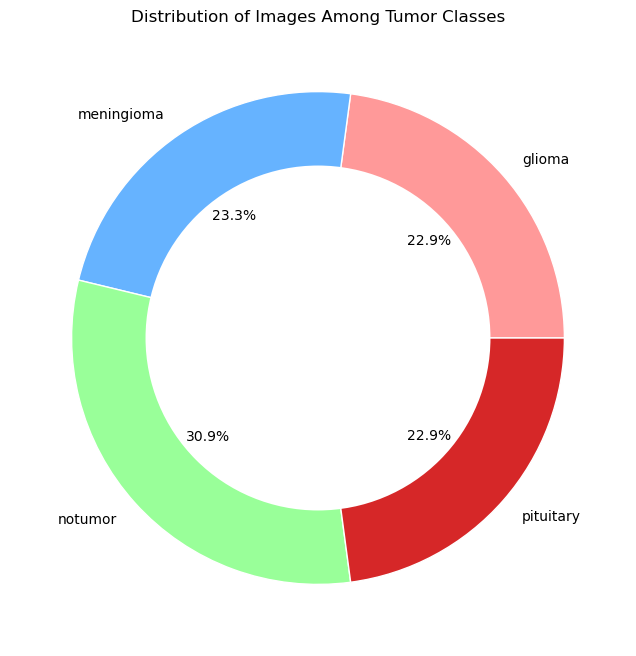

In [3]:
# Display Number of Images Per Class

import os
import matplotlib.pyplot as plt

total_image_count = 0
class_counts = {'glioma': 0, 'meningioma': 0, 'notumor': 0, 'pituitary': 0}

# Define the base path to the folders
images_path = Path("D:\Brain Dataset\data")

# Define the paths to the folders
folder_paths = [os.path.join(images_path, 'glioma'), 
                os.path.join(images_path, 'meningioma'),
                os.path.join(images_path, 'notumor'), 
                os.path.join(images_path, 'pituitary')]

# Loop through each folder path
for folder_path, class_name in zip(folder_paths, class_counts.keys()):
    image_count = len(os.listdir(folder_path))
    print(f"{class_name}: {image_count}")
    class_counts[class_name] = image_count
    total_image_count += image_count

# Display total count of images
print("Total number of images in all folders:", total_image_count)

# Plotting the donut chart
plt.figure(figsize=(8, 8))
wedges, texts, autotexts = plt.pie(class_counts.values(), labels=class_counts.keys(), autopct='%1.1f%%', wedgeprops=dict(width=0.4, edgecolor='w'))

# Customizing colors
colors = ['#ff9999', '#66b3ff', '#99ff99']
for wedge, color in zip(wedges, colors):
    wedge.set_facecolor(color)

# Draw a circle at the center to make it a donut chart
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Distribution of Images Among Tumor Classes')
plt.show()

# Display 1 Image per class

C:\Users\aipc 7\AppData\Local\Temp\ipykernel_2464\1976551654.py:16: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


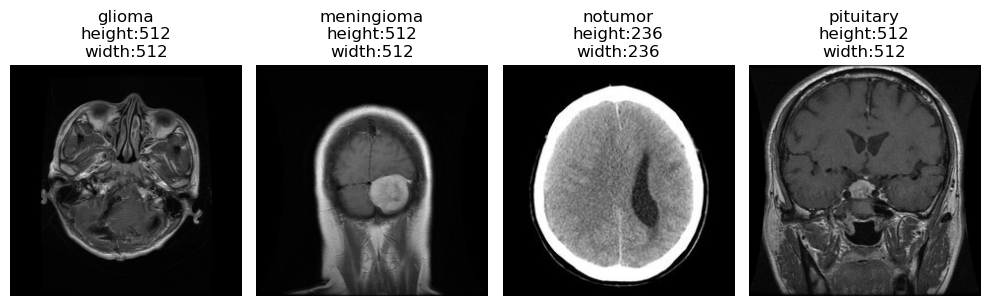

In [4]:
# Display 1 Image per class

fig,ax = plt.subplots(1,4,figsize=(10,4))
ax = ax.flat
for i,c in enumerate(total_classes):
  img_total_class = list(Path(os.path.join(images_path, c)).glob("*.jpg"))
  img_selected = random.choice(img_total_class)
  img_BGR = cv2.imread(str(img_selected))
  img_RGB = cv2.cvtColor(img_BGR, cv2.COLOR_BGR2RGB)
  height,width,channel = img_RGB.shape
  ax[i].imshow(img_RGB)
  ax[i].set_title(f"{img_selected.parent.stem}\nheight:{height}\nwidth:{width}")
  ax[i].axis("off")

fig.tight_layout()
fig.show()

# Split Dataset into Training & Testing

In [5]:
#import splitfolders  # or import split_folders

#input_folder = 'D:\Brain Dataset\data'

#splitfolders.ratio(input_folder, output="D:\Brain Dataset\data", 
                   #seed=42, ratio=(.7, .3), 
                   #group_prefix=None) # default values

# Split Dataset into Training & Testing


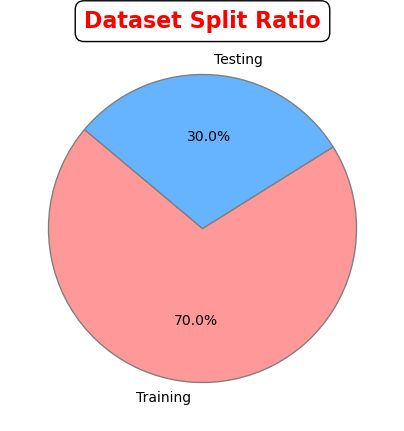

In [6]:

import matplotlib.pyplot as plt

# Define the split ratio
split_ratio = [70, 30]  # Assuming 70% for training and 30% for testing

# Define custom colors
colors = ['#ff9999', '#66b3ff']

# Plot the pie chart with custom design
plt.figure(figsize=(5, 5))  # Change figure size
plt.pie(split_ratio, labels=['Training', 'Testing'], autopct='%1.1f%%', startangle=140, colors=colors,
        wedgeprops={'edgecolor': 'gray'})  # Change color and wedgeprops
plt.title('Dataset Split Ratio', fontsize=16, color='red', fontweight='bold', loc='center', bbox=dict(facecolor='none', edgecolor='black', boxstyle='round,pad=0.4'))  # Change title font size, color, weight and add border
plt.show()

# After splitting images in per class

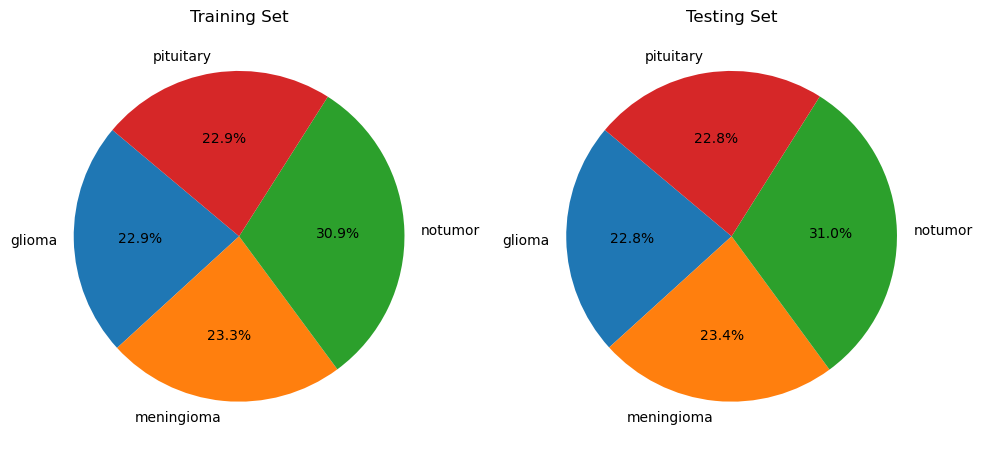

Training Set:
glioma: 210
meningioma: 214
notumor: 283
pituitary: 210

Testing Set:
glioma: 90
meningioma: 92
notumor: 122
pituitary: 90


In [7]:
import matplotlib.pyplot as plt
import os

# Function to count images in each class
def count_images(folder):
    class_counts = {}
    for class_name in os.listdir(folder):
        if os.path.isdir(os.path.join(folder, class_name)):
            class_counts[class_name] = len(os.listdir(os.path.join(folder, class_name)))
    return class_counts

# Define the paths to the folders
train_folder = 'D:\Brain Dataset\Splitting\Training'
val_folder = 'D:\Brain Dataset\Splitting\Testing'

# Count images in training and validation sets
train_class_counts = count_images(train_folder)
val_class_counts = count_images(val_folder)

# Plotting the pie chart for training set
plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
plt.pie(train_class_counts.values(), labels=train_class_counts.keys(), autopct='%1.1f%%', startangle=140)
plt.title('Training Set')

# Plotting the pie chart for testing set
plt.subplot(1, 2, 2)
plt.pie(val_class_counts.values(), labels=val_class_counts.keys(), autopct='%1.1f%%', startangle=140)
plt.title('Testing Set')

plt.tight_layout()
plt.show()

# Print the counts
print("Training Set:")
for class_name, count in train_class_counts.items():
    print(f"{class_name}: {count}")
    
print("\nTesting Set:")
for class_name, count in val_class_counts.items():
    print(f"{class_name}: {count}")

In [8]:
# Data Cleaning Process

#Remove Duplicate Images

import os
import cv2
import hashlib

# Path to the directory containing the images
dataset_dir = r"D:\Brain Dataset\data"

# Function to remove duplicate images
def remove_duplicates(dataset_dir):
    unique_images = set()
    for image_file in os.listdir(dataset_dir):
        image_path = os.path.join(dataset_dir, image_file)
        image = cv2.imread(image_path)
        if image is not None:
            # Convert the image to a hash
            image_hash = hashlib.md5(image.tobytes()).hexdigest()
            # Check if the hash is already in the set
            if image_hash not in unique_images:
                unique_images.add(image_hash)
            else:
                # Remove duplicate image
                print(f"Removing duplicate image: {image_path}")
                os.remove(image_path)

# Call the function to remove duplicates
remove_duplicates(dataset_dir)

print("Succussfully removed duplicate samples")

Succussfully removed duplicate samples


In [9]:
# Correction of Mislabelled Images

import os
import shutil

# Function to extract label from filename
def extract_label(filename):
    label = filename.split('.')[0]  # Assuming filenames are the labels
    return label

# Function to find mislabelled images in a directory
def find_mislabelled_images(directory):
    mislabelled_images = []
    for filename in os.listdir(directory):
        img_path = os.path.join(directory, filename)
        true_label = extract_label(filename)
        # No prediction logic needed, as labels are directly extracted from filenames
        # Assuming your filenames are in the format 'label.extension' (e.g., 'cat.jpg')
        predicted_label = true_label  # No prediction, directly using true label as predicted label
        if predicted_label != true_label:
            mislabelled_images.append((img_path, true_label, predicted_label))
    return mislabelled_images

# Function to correct mislabelled images
def correct_mislabelled_images(mislabelled_images):
    for img_path, true_label, predicted_label in mislabelled_images:
        print(f"Image: {img_path}, True Label: {true_label}, Predicted Label: {predicted_label}")
        new_label = input(f"Enter the correct label for {img_path}: ")
        # Move the image to a new directory with the correct label as its name
        new_path = os.path.join(new_label, os.path.basename(img_path))
        os.makedirs(os.path.dirname(new_path), exist_ok=True)
        shutil.move(img_path, new_path)
        print(f"Image moved to {new_path} with label {new_label}")

# Directory containing images
image_directory = 'D:\Brain Dataset\data'

# Find mislabelled images
mislabelled_images = find_mislabelled_images(image_directory)

# Correct mislabelled images
correct_mislabelled_images(mislabelled_images)

print("All mislabelled images have been corrected.")



All mislabelled images have been corrected.


In [10]:
import os

def check_mislabeled_images(dataset_path):
    mislabeled_images_found = False
    for filename in os.listdir(dataset_path):
        if "image" in filename.lower() and "photo" in filename.lower():
            print("Mislabelled image found:", filename)
            mislabeled_images_found = True
    if not mislabeled_images_found:
        print("No mislabeled images found in the dataset.")

# Provide the path to your dataset directory
dataset_path = "D:\Brain Dataset\data"
check_mislabeled_images(dataset_path)

No mislabeled images found in the dataset.


# Resizing

In [11]:
#Function to preprocess the images
def preprocess_image(image):
    #bResizeb the Images to the desired size
    resized_image = cv2.resize(image, (224, 224))

# Data Augumentation

In [32]:
from tqdm import tqdm
from keras.preprocessing.image import ImageDataGenerator

# Define data augmentation parameters
datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True,
    vertical_flip=True,  # Additional augmentation
    fill_mode='nearest'
)


labels = ['glioma','meningioma','notumor','pituitary']

X_train = []
y_train = []
image_size = 227
augmented_images_per_original = 9  # Number of augmented images per original image

for i in labels:
    folderPath = os.path.join('D:\Brain Dataset\Splitting', 'Training', i)
    for j in tqdm(os.listdir(folderPath)):
        img = cv2.imread(os.path.join(folderPath, j))
        img = cv2.resize(img, (image_size, image_size))
        X_train.append(img)
        y_train.append(i)
       
        # Apply data augmentation
        augmented_images_count = 0
        for X_batch, y_batch in datagen.flow(np.expand_dims(img, axis=0), np.array([labels.index(i)]), batch_size=1):
            X_train.append(X_batch[0])
            y_train.append(i)
            augmented_images_count += 1
            if augmented_images_count >= augmented_images_per_original:
                break  # Stop augmentation for this image


for i in labels:
    folderPath = os.path.join('D:\Brain Dataset\Splitting', 'Testing',i)
    for j in tqdm(os.listdir(folderPath)):
        img = cv2.imread(os.path.join(folderPath,j))
        img = cv2.resize(img,(image_size,image_size))
        X_train.append(img)
        y_train.append(i)
X_train = np.array(X_train)
y_train = np.array(y_train)

# Normalizing the images
X_train = X_train / 255.0
X_test = X_test / 255.0


100%|██████████████████████████████████████████████████████████████████████████████████| 90/90 [00:03<00:00, 25.97it/s]


In [33]:
from sklearn.utils import shuffle
X_train, y_train = shuffle(X_train,y_train, random_state=152)


In [34]:
X_train.shape

(9564, 227, 227, 3)

In [35]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X_train,y_train, test_size=0.3,random_state=156)


In [36]:
import tensorflow as tf

y_train_new = []
for i in y_train:
    y_train_new.append(labels.index(i))
y_train = y_train_new
y_train = tf.keras.utils.to_categorical(y_train)


y_test_new = []
for i in y_test:
    y_test_new.append(labels.index(i))
y_test = y_test_new
y_test = tf.keras.utils.to_categorical(y_test)


# SqueezeNet Model

In [37]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, concatenate, Dropout, GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adamc 
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

from tensorflow.keras.layers import BatchNormalization

def fire_module(x, squeeze, expand):
    squeezed = Conv2D(squeeze, (1, 1), activation='relu', padding='same')(x)
    squeezed = BatchNormalization()(squeezed)  # Add Batch Normalization
    expanded_1x1 = Conv2D(expand, (1, 1), activation='relu', padding='same')(squeezed)
    expanded_1x1 = BatchNormalization()(expanded_1x1)  # Add Batch Normalization
    expanded_3x3 = Conv2D(expand, (3, 3), activation='relu', padding='same')(squeezed)
    expanded_3x3 = BatchNormalization()(expanded_3x3)  # Add Batch Normalization
    return concatenate([expanded_1x1, expanded_3x3], axis=-1)

def SqueezeNet(input_shape, classes):
    input_img = Input(shape=input_shape)

    x = Conv2D(96, (7, 7), activation='relu', strides=(2, 2), padding='same')(input_img)
    x = BatchNormalization()(x)  # Add Batch Normalization
    x = MaxPooling2D(pool_size=(3, 3), strides=(2, 2), padding='same')(x)

    x = fire_module(x, squeeze=16, expand=64)
    x = fire_module(x, squeeze=16, expand=64)
    x = fire_module(x, squeeze=32, expand=128)
    x = MaxPooling2D(pool_size=(3, 3), strides=(2, 2), padding='same')(x)

    x = fire_module(x, squeeze=32, expand=128)
    x = fire_module(x, squeeze=48, expand=192)
    x = fire_module(x, squeeze=48, expand=192)
    x = fire_module(x, squeeze=64, expand=256)
    x = MaxPooling2D(pool_size=(3, 3), strides=(2, 2), padding='same')(x)

    x = fire_module(x, squeeze=64, expand=256)
    x = Dropout(0.5)(x)

    x = Conv2D(classes, (1, 1), activation='relu', padding='valid')(x)
    x = GlobalAveragePooling2D()(x)
    out = Dense(classes, activation='softmax')(x)

    model = Model(inputs=input_img, outputs=out)
    return model


# Define input shape and number of classes
input_shape = (224, 224, 3)
num_classes = 4 

In [38]:
# Define ModelCheckpoint callback to save the best model during training for SqueezeNet
checkpoint_SqueezeNet = tf.keras.callbacks.ModelCheckpoint(filepath='best_model_SqueezeNet.h5',
                                                            monitor='val_accuracy',
                                                            save_best_only=True,
                                                            mode='max',
                                                            verbose=1,
                                                            save_weights_only=False)  # Save the entire model instead of just weights


In [39]:
import time
import tensorflow as tf
from tensorflow.keras.callbacks import TensorBoard, ModelCheckpoint, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define data generators for training and validation
train_datagen = ImageDataGenerator(validation_split=0.3)  # Splitting the data into training and validation sets
train_generator = train_datagen.flow(X_train, y_train, batch_size=8, subset='training')
validation_generator = train_datagen.flow(X_train, y_train, batch_size=8, subset='validation')

# Create SqueezeNet model
model_squeezenet = SqueezeNet(input_shape=(224, 224, 3), classes=4)

# Compile the model
adam_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
model_squeezenet.compile(loss="categorical_crossentropy", optimizer=adam_optimizer, metrics=['accuracy'])

# Train the model and measure time
start_time = time.time()
history = model_squeezenet.fit(train_generator,
                               steps_per_epoch=len(train_generator),
                               validation_data=validation_generator,
                               validation_steps=len(validation_generator),
                               epochs=50,  # Setting epochs to 50
                               callbacks=[TensorBoard(log_dir='./logs'),
                                          ModelCheckpoint(filepath='best_model_squeezenet.h5',
                                                          monitor='val_accuracy',
                                                          save_best_only=True,
                                                          mode='max',
                                                          verbose=1),  # Added verbose for clarity
                                          EarlyStopping(monitor='val_accuracy', patience=100)])
training_time = time.time() - start_time

# Evaluate the model
start_time = time.time()
loss, accuracy = model_squeezenet.evaluate(X_test, y_test)
testing_time = time.time() - start_time

# Print the training and testing times
print("Training Time: {:.2f} seconds".format(training_time))
print("Testing Time: {:.2f} seconds".format(testing_time))


Epoch 1/50
586/586 [==============================] - ETA: 0s - loss: 1.0163 - accuracy: 0.5721
Epoch 1: val_accuracy improved from -inf to 0.38795, saving model to best_model_squeezenet.h5
586/586 [==============================] - 337s 520ms/step - loss: 1.0163 - accuracy: 0.5721 - val_loss: 2.1530 - val_accuracy: 0.3879
Epoch 2/50
586/586 [==============================] - ETA: 0s - loss: 0.8293 - accuracy: 0.6522
Epoch 2: val_accuracy improved from 0.38795 to 0.44273, saving model to best_model_squeezenet.h5
586/586 [==============================] - 242s 413ms/step - loss: 0.8293 - accuracy: 0.6522 - val_loss: 1.6782 - val_accuracy: 0.4427
Epoch 3/50
586/586 [==============================] - ETA: 0s - loss: 0.7433 - accuracy: 0.6944
Epoch 3: val_accuracy improved from 0.44273 to 0.47759, saving model to best_model_squeezenet.h5
586/586 [==============================] - 247s 421ms/step - loss: 0.7433 - accuracy: 0.6944 - val_loss: 3.7977 - val_accuracy: 0.4776
Epoch 4/50
586/586 

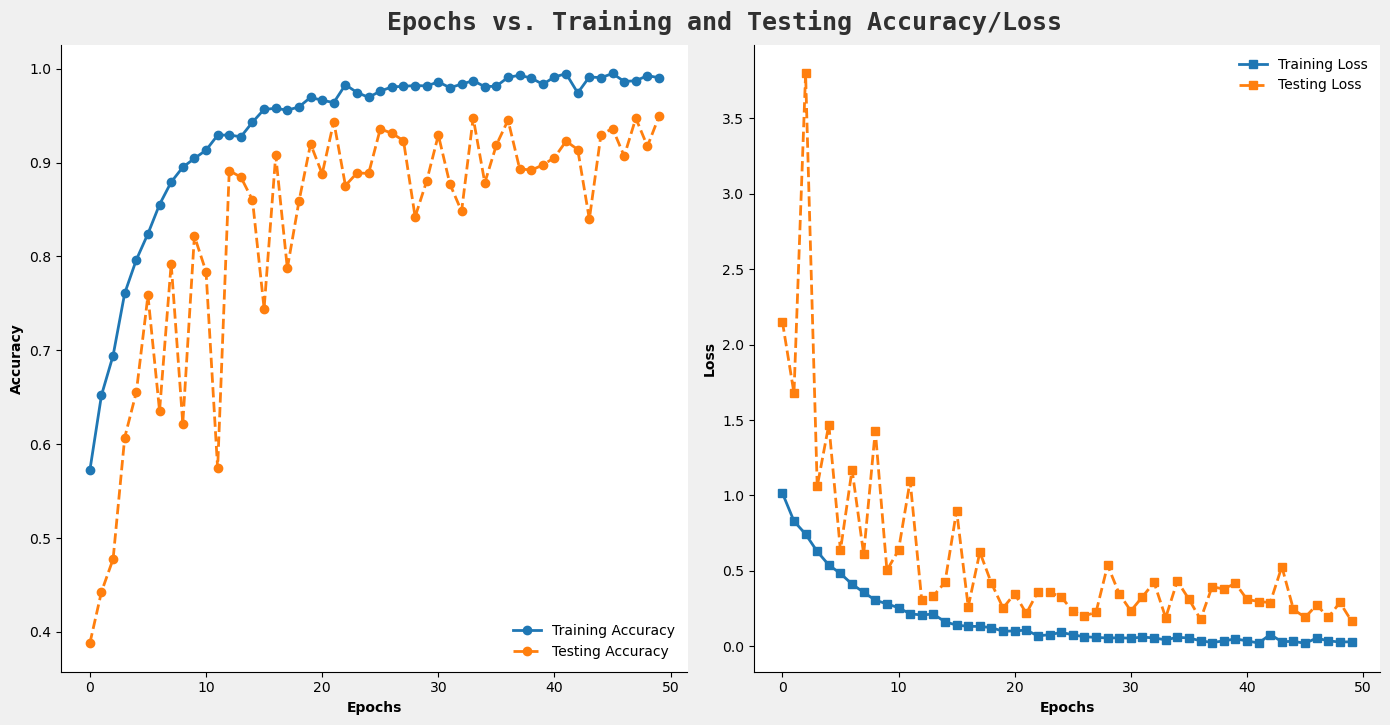

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ignoring warnings
import warnings
warnings.filterwarnings('ignore')

epochs = [i for i in range(50)]
fig, ax = plt.subplots(1, 2, figsize=(14, 7))

# Set background color
fig.patch.set_facecolor('#f0f0f0')

# Set the border color around the figure
fig.patch.set_edgecolor('black')

train_acc = history.history['accuracy']
train_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

fig.text(s='Epochs vs. Training and Testing Accuracy/Loss', size=18, fontweight='bold',
             fontname='monospace', color='black', y=1, x=0.28, alpha=0.8)

# Plotting Training and Validation Accuracy
sns.despine()
ax[0].plot(epochs, train_acc, marker='o', linestyle='-', label='Training Accuracy', linewidth=2)
ax[0].plot(epochs, val_acc, marker='o', linestyle='--', label='Testing Accuracy', linewidth=2)
ax[0].legend(frameon=False, fontsize='medium', loc='lower right')
ax[0].set_xlabel('Epochs', fontsize='medium', fontweight='bold')
ax[0].set_ylabel('Accuracy', fontsize='medium', fontweight='bold')
ax[0].tick_params(axis='both', which='major', labelsize='medium')

# Plotting Training and Validation Loss
sns.despine()
ax[1].plot(epochs, train_loss, marker='s', linestyle='-', label='Training Loss', linewidth=2)
ax[1].plot(epochs, val_loss, marker='s', linestyle='--', label='Testing Loss', linewidth=2)
ax[1].legend(frameon=False, fontsize='medium', loc='upper right')
ax[1].set_xlabel('Epochs', fontsize='medium', fontweight='bold')
ax[1].set_ylabel('Loss', fontsize='medium', fontweight='bold')
ax[1].tick_params(axis='both', which='major', labelsize='medium')

plt.tight_layout()
plt.show()

In [41]:
pred = model_squeezenet.predict(X_test)
pred = np.argmax(pred,axis=1)
y_test_new = np.argmax(y_test,axis=1)

90/90 [==============================] - 53s 511ms/step


In [42]:
print(classification_report(y_test_new,pred))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94       622
           1       0.93      0.90      0.92       684
           2       0.98      0.98      0.98       913
           3       0.97      0.94      0.96       651

    accuracy                           0.95      2870
   macro avg       0.95      0.95      0.95      2870
weighted avg       0.95      0.95      0.95      2870



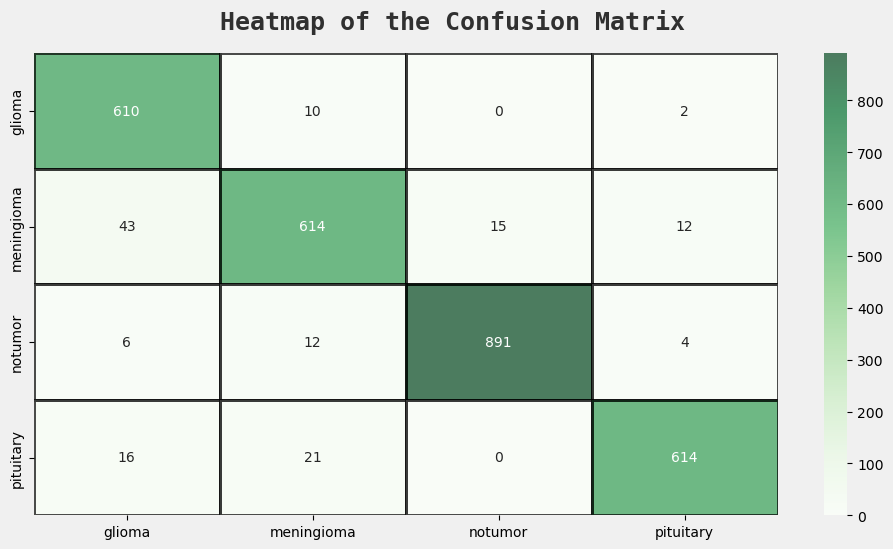

In [43]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# Set background color and corner border
fig.patch.set_facecolor('#f0f0f0')
fig.patch.set_edgecolor('black')

# Plot heatmap
sns.heatmap(confusion_matrix(y_test_new, pred), ax=ax, xticklabels=labels, yticklabels=labels, annot=True,
            cmap='Greens', alpha=0.7, linewidths=2, linecolor='black', fmt='d')

# Add title
fig.text(s='Heatmap of the Confusion Matrix', size=18, fontweight='bold', fontname='monospace',
             color='black', y=0.92, x=0.28, alpha=0.8)

plt.show()